In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
import phd_parser as pp

In [3]:
from phd_parser.raman.btc655n import extract_lines, split_lines, parse_metadata_lines, parse_data_lines, read_export

In [4]:
MOCK_RAMAN_FILE = Path(r"..\tests\raman\TiO2-2x5cm.txt")

In [5]:
lines = extract_lines(MOCK_RAMAN_FILE)
meta_lines, header_line, data_lines = split_lines(lines)

In [6]:
meta = parse_metadata_lines(meta_lines)
meta

{'File Version': 'BWSpec4.04_00',
 'Date': '2026-03-25 17:03:42',
 'title': 'RBU',
 'model': 'BTC655N',
 'c code': 'RBU',
 'operator': '',
 'port1': 0.0,
 'baud1': 3.0,
 'pixel_start': 0.0,
 'pixel_end': 2047.0,
 'step': 1.0,
 'units': 0.0,
 'bkcolor': 16777215.0,
 'show_mode': 3.0,
 'data_mode': 0.0,
 'pixel_mode': 0.0,
 'intigration times(ms)': 10000.0,
 'average number': 5.0,
 'time_multiply': 1.0,
 'spectrometer_type': 74.0,
 'yaxis': 1.0,
 'yaxis_min': 0.0,
 'yaxis_max': 65535.0,
 'xaxis': 1.0,
 'xaxis_min': 8.0,
 'xaxis_max': 2026.0,
 'irrands_DispWLMin': 100.0,
 'irrands_DispWLMax': 1000.0,
 'yaxis_min_6': 0.0,
 'yaxis_max_6': 0.0,
 'irradiance_unit': 0.0,
 'Color_Data_Flag': 0.0,
 'Color_StartWL': 771.0,
 'Color_EndWL': 778.0,
 'Color_IncWL': 10.0,
 'power_unit_index': 1.0,
 'photometric_index': 0.0,
 'Illuminant_index': 2.0,
 'observer_index': 0.0,
 'lab_l': 0.0,
 'lab_a': 0.0,
 'lab_b': 0.0,
 'radiometric_flag': 0.0,
 'coefs_a0': 770.896580728023,
 'coefs_a1': 0.1270880634662

In [7]:
data = parse_data_lines(data_lines, header_line)
data

,Pixel,Wavelength,Wavenumber,Raman Shift,Dark,Reference,Raw data #1,Dark Subtracted #1,%TR #1,Absorbance #1,Irradiance (lumen) #1
0,0,555.0,65535.0,566.8,13.8667,0.0,0.0,0.0,NaN,NaN,NaN
1,1,234.4,65535.0,229.2,-3.1333,0.0,0.0,0.0,NaN,NaN,NaN
2,2,221.6,65535.0,218.2,-1.3333,0.0,0.0,0.0,NaN,NaN,NaN
3,3,221.8,65535.0,217.4,-2.3333,0.0,0.0,0.0,NaN,NaN,NaN
4,4,220.2,65535.0,216.0,-2.1333,0.0,0.0,0.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2043,2043,583.4,65535.0,596.0,14.6667,0.0,0.0,0.0,NaN,NaN,NaN
2044,2044,469.2,65535.0,486.0,18.8667,0.0,0.0,0.0,NaN,NaN,NaN
2045,2045,438.0,65535.0,458.6,22.6667,0.0,0.0,0.0,NaN,NaN,NaN
2046,2046,454.8,65535.0,472.6,19.8667,0.0,0.0,0.0,NaN,NaN,NaN


In [8]:
raman = read_export(MOCK_RAMAN_FILE)
raman["meta"]

{'File Version': 'BWSpec4.04_00',
 'Date': '2026-03-25 17:03:42',
 'title': 'RBU',
 'model': 'BTC655N',
 'c code': 'RBU',
 'operator': '',
 'port1': 0.0,
 'baud1': 3.0,
 'pixel_start': 0.0,
 'pixel_end': 2047.0,
 'step': 1.0,
 'units': 0.0,
 'bkcolor': 16777215.0,
 'show_mode': 3.0,
 'data_mode': 0.0,
 'pixel_mode': 0.0,
 'intigration times(ms)': 10000.0,
 'average number': 5.0,
 'time_multiply': 1.0,
 'spectrometer_type': 74.0,
 'yaxis': 1.0,
 'yaxis_min': 0.0,
 'yaxis_max': 65535.0,
 'xaxis': 1.0,
 'xaxis_min': 8.0,
 'xaxis_max': 2026.0,
 'irrands_DispWLMin': 100.0,
 'irrands_DispWLMax': 1000.0,
 'yaxis_min_6': 0.0,
 'yaxis_max_6': 0.0,
 'irradiance_unit': 0.0,
 'Color_Data_Flag': 0.0,
 'Color_StartWL': 771.0,
 'Color_EndWL': 778.0,
 'Color_IncWL': 10.0,
 'power_unit_index': 1.0,
 'photometric_index': 0.0,
 'Illuminant_index': 2.0,
 'observer_index': 0.0,
 'lab_l': 0.0,
 'lab_a': 0.0,
 'lab_b': 0.0,
 'radiometric_flag': 0.0,
 'coefs_a0': 770.896580728023,
 'coefs_a1': 0.1270880634662

In [9]:
data.columns

Index(['Pixel', 'Wavelength', 'Wavenumber', 'Raman Shift', 'Dark', 'Reference',
       'Raw data #1', 'Dark Subtracted #1', '%TR #1', 'Absorbance #1',
       'Irradiance (lumen) #1'],
      dtype='str')

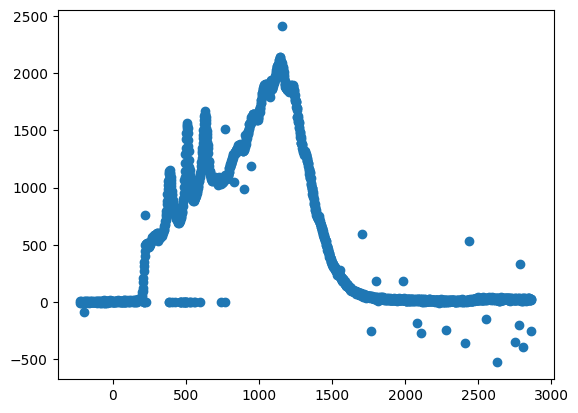

In [12]:
fig, ax = plt.subplots()
ax.scatter(data['Raman Shift'], data['Dark Subtracted #1'])